# Adversarial Search: Playing Connect 4

Student Name: [Add your name]

I have used the following AI tools: [list tools]

I understand that my submission needs to be my own work: [your initials]

## Learning Outcomes

* Implement adversarial search algorithms for strategic game play.
* Analyze and optimize search in complex game spaces.
* Design effective heuristic evaluation functions.
* Compare performance across different agent strategies.
* Evaluate algorithmic trade-offs between decision quality and efficiency.

## Instructions

Total Points: Undergraduates 100, graduate students 110

Complete this notebook and submit it. The notebook needs to be a complete project report with your implementation, documentation including a short discussion of how your implementation works and your design choices, and experimental results (e.g., tables and charts with simulation results) with a short discussion of what they mean. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the completely rendered notebook as a HTML file. 


## Introduction

You will implement different versions of agents that play Connect 4:

> "Connect 4 is a two-player connection board game, in which the players choose a color and then take turns dropping colored discs into a seven-column, six-row vertically suspended grid. The pieces fall straight down, occupying the lowest available space within the column. The objective of the game is to be the first to form a horizontal, vertical, or diagonal line of four of one's own discs." (see [Connect Four on Wikipedia](https://en.wikipedia.org/wiki/Connect_Four))

Note that [Connect-4 has been solved](https://en.wikipedia.org/wiki/Connect_Four#Mathematical_solution)
in 1988. A connect-4 solver with a discussion of how to solve different parts of the problem can be found here: https://connect4.gamesolver.org/en/

## Task 1: Defining the Search Problem [10 point]

Define the components of the search problem:

* Initial state
* Actions
* Transition model (result function)
* Goal state (terminal state and utility)

Describe each component and then implement it as a function that can be used by search algorithms.

In [25]:
# Your code/answer goes here.
import numpy as np
from typing import List, Tuple, Optional
import random
import time
import math

def empty_board(shape=(6, 7)):
    return np.full(shape=shape, fill_value=0, dtype=int)

def actions(state: np.ndarray) -> List[int]:
    """Return list of valid columns where a piece can be dropped."""
    n_rows, n_cols = state.shape
    return [c for c in range(n_cols) if state[0, c] == 0]

def result(state: np.ndarray, player: int, action: int) -> np.ndarray:
    """Return a new state after dropping 'player' piece into column 'action'."""
    n_rows, _ = state.shape
    if state[0, action] != 0:
        raise ValueError("Invalid action: column is full")
    new_state = state.copy()
    # find lowest empty row in the column
    for r in range(n_rows-1, -1, -1):
        if new_state[r, action] == 0:
            new_state[r, action] = player
            break
    return new_state

def _line_winner(line: List[int]) -> int:
    """Helper: check a 1D list for 4-in-a-row. Return 1, -1 or 0."""
    cnt = 0
    last = 0
    for v in line:
        if v != 0 and v == last:
            cnt += 1
        else:
            cnt = 1
            last = v
        if last != 0 and cnt >= 4:
            return last
    return 0

def winner(state: np.ndarray) -> int:
    """Return 1 if player 1 wins, -1 if player -1 wins, 0 otherwise."""
    n_rows, n_cols = state.shape
    # rows
    for r in range(n_rows):
        w = _line_winner(list(state[r, :]))
        if w: return w
    # cols
    for c in range(n_cols):
        w = _line_winner(list(state[:, c]))
        if w: return w
    # diag /
    for r in range(n_rows-1, -1, -1):
        for c in range(n_cols):
            diag = []
            rr, cc = r, c
            while 0 <= rr < n_rows and 0 <= cc < n_cols:
                diag.append(state[rr, cc])
                rr -= 1; cc += 1
            if len(diag) >= 4:
                w = _line_winner(diag)
                if w: return w
    # diag \
    for r in range(n_rows):
        for c in range(n_cols):
            diag = []
            rr, cc = r, c
            while 0 <= rr < n_rows and 0 <= cc < n_cols:
                diag.append(state[rr, cc])
                rr += 1; cc += 1
            if len(diag) >= 4:
                w = _line_winner(diag)
                if w: return w
    return 0

def terminal(state: np.ndarray) -> bool:
    """Game is over if someone wins or no actions remain."""
    return winner(state) != 0 or len(actions(state)) == 0

def utility(state: np.ndarray, player: int) -> int:
    """Utility from 'player' perspective: +1 win, -1 loss, 0 draw/ongoing."""
    w = winner(state)
    if w == player:
        return 1
    elif w == -player:
        return -1
    else:
        return 0


How big is the state space? Give an estimate and explain it.

- Your answer goes here.
- Ước lượng không chặt: mỗi ô có 3 trạng thái {1, -1, 0} ⇒ tối đa 3^(6*7) = 3^42 ≈ 1.094×10^20.
- Tuy nhiên, nhiều trạng thái là không hợp lệ (do quân phải “rơi xuống dưới”).
- Một ước lượng thực tế hơn (đếm trạng thái hợp lệ) vẫn là cỡ ~10^19–10^20 (rất lớn).

How big is the game tree that minimax search will go through? Give an estimate and explain it.

- Your answer goes here.
- Branching factor trung bình ~4–7 (tối đa 7 cột). Độ sâu tối đa ~42 lượt.
- Kích thước cây ~ b^d ≈ 7^42 ≈ 1.3×10^35 (ước lượng biên trên; thực tế nhỏ hơn do cắt sớm khi thắng/hòa).
- Dù vậy vẫn là khổng lồ ⇒ minimax đầy đủ trên 6x7 là không khả thi.

## Task 2: Game Environment and Random Agent [25 point]

Use a numpy character array as the board.

In [26]:
import numpy as np

def empty_board(shape=(6, 7)):
    return np.full(shape=shape, fill_value=0)

print(empty_board())

[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]]


The standard board is $6 \times 7$ but you can use smaller boards to test your code. Instead of colors (red and yellow), I use 1 and -1 to represent the players. Make sure that your agent functions all have the from: `agent_type(board, player = 1)`, where board is the current board position (in the format above) and player is the player whose next move it is and who the agent should play (as 1 and -1).

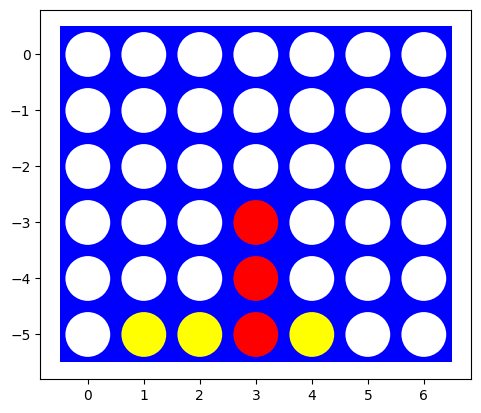

In [27]:
# Visualization code by Randolph Rankin

import matplotlib.pyplot as plt

def visualize(board):
    plt.axes()
    rectangle=plt.Rectangle((-0.5,len(board)*-1+0.5),len(board[0]),len(board),fc='blue')
    circles=[]
    for i,row in enumerate(board):
        for j,val in enumerate(row):
            color='white' if val==0 else 'red' if val==1 else 'yellow'
            circles.append(plt.Circle((j,i*-1),0.4,fc=color))

    plt.gca().add_patch(rectangle)
    for circle in circles:
        plt.gca().add_patch(circle)

    plt.axis('scaled')
    plt.show()
    
board = [[0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 1, 0, 0, 0],
         [0, 0, 0, 1, 0, 0, 0],
         [0,-1,-1, 1,-1, 0, 0]]
visualize(board)

Implement helper functions for:

* A check for available actions in each state `actions(state)`.
* The transition model `result(state, player, action)`.
* Check for terminal states `terminal(state)`.
* The utility function `utility(state, player)`.

The player argument is used so your agent can play red or yellow.
Make sure that all these functions work with boards of different sizes (number of columns and rows).
You can follow the [tic-tac-toe example from class.](https://colab.research.google.com/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_definitions.ipynb)

In [28]:
# Your code/ answer goes here.
b = empty_board((4,4))
print("actions:", actions(b))
b = result(b, 1, action=0)
b = result(b, -1, action=0)
b = result(b, 1, action=1)
print(b)
print("terminal?", terminal(b), "utility P1:", utility(b, 1))

actions: [0, 1, 2, 3]
[[ 0  0  0  0]
 [ 0  0  0  0]
 [-1  0  0  0]
 [ 1  1  0  0]]
terminal? False utility P1: 0


Implement an agent that plays randomly. Make sure the agent function receives as the percept the board and returns a valid action. Use an agent function definition with the following signature (arguments):

`def random_player(board, player = 1): ...`

The argument `player` is used for agents that do not store what color they are playing. The value passed on by the environment should be 1 ot -1 for player red and yellow, respectively.  See [Experiments section for tic-tac-toe](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_and_or_tree_search.ipynb#Experiments) for an example.

In [29]:
# Your code/ answer goes here.
def random_player(board: np.ndarray, player: int = 1) -> int:
    """Return a random valid column."""
    acts = actions(board)
    return random.choice(acts) if acts else -1


Let two random agents play against each other 1000 times. Look at the [Experiments section for tic-tac-toe](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_and_or_tree_search.ipynb#Experiments) to see how the environment uses the agent functions to play against each other.

How often does each player win? Is the result expected?

In [30]:
# Your code/ answer goes here.
def play_game(agent_red, agent_yellow, shape=(6,7), render=False, max_turns=1000):
    """Return winner (1, -1) or 0 for draw."""
    state = empty_board(shape)
    player = 1  # red starts
    for _ in range(max_turns):
        if terminal(state):
            return winner(state)
        act = agent_red(state, 1) if player == 1 else agent_yellow(state, -1)
        if act == -1:  # no move
            return winner(state)
        state = result(state, player, act)
        player *= -1
        if render:
            visualize(state.tolist())
    return winner(state)

# Run 1000 self-play random vs random (không render để nhanh)
def eval_random_vs_random(n_games=1000, shape=(6,7)):
    red_w = yel_w = draws = 0
    for _ in range(n_games):
        w = play_game(random_player, random_player, shape=shape)
        if w == 1: red_w += 1
        elif w == -1: yel_w += 1
        else: draws += 1
    return red_w, yel_w, draws

red, yellow, draw = eval_random_vs_random(1000, shape=(6,7))
print(red, yellow, draw)


567 432 1


## Task 3: Minimax Search with Alpha-Beta Pruning

### Implement the Search [20 points] 

Implement minimax search starting from a given board for specifying the player.

__Important Notes:__ 
* You can use code from the [tic-tac-toe example](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_alpha_beta_tree_search.ipynb).
* Make sure that all your agent functions have a signature consistent with the random agent above and that it [uses a class to store state information.](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/HOWTOs/store_agent_state_information.ipynb)
This is essential to be able play against agents from other students later.
* The game tree for a $6 \times 7$ board is huge and optimal algorithms need to visit each or a large percentage of all nodes in the tree. You can experiment with smaller boards like a $4 \times 4$ board first.

In [31]:
# Your code/ answer goes here.
class MinimaxABAgent:
    def __init__(self, max_player: int = 1, use_move_ordering: bool = False):
        self.max_player = max_player
        self.use_move_ordering = use_move_ordering
        self.nodes = 0  # thống kê

    def _order_moves(self, state: np.ndarray, moves: List[int]) -> List[int]:
        if not self.use_move_ordering:
            return moves
        # Ưu tiên cột gần trung tâm
        n_cols = state.shape[1]
        center = (n_cols - 1) / 2.0
        return sorted(moves, key=lambda c: abs(c - center))

    def _minimax(self, state: np.ndarray, player: int, alpha: float, beta: float) -> Tuple[float, Optional[int]]:
        self.nodes += 1
        if terminal(state):
            return float(utility(state, self.max_player)), None

        best_move = None
        moves = self._order_moves(state, actions(state))

        if player == self.max_player:
            value = -float('inf')
            for a in moves:
                child = result(state, player, a)
                sc, _ = self._minimax(child, -player, alpha, beta)
                if sc > value:
                    value, best_move = sc, a
                alpha = max(alpha, value)
                if alpha >= beta:
                    break  # beta cut
            return value, best_move
        else:
            value = float('inf')
            for a in moves:
                child = result(state, player, a)
                sc, _ = self._minimax(child, -player, alpha, beta)
                if sc < value:
                    value, best_move = sc, a
                beta = min(beta, value)
                if alpha >= beta:
                    break  # alpha cut
            return value, best_move

    def __call__(self, board: np.ndarray, player: int = 1) -> int:
        # choose move for `player` using minimax+AB to terminal
        self.max_player = player
        self.nodes = 0
        _, move = self._minimax(board, player, -float('inf'), float('inf'))
        return move if move is not None else -1


Experiment with some manually created boards (at least 5) to check if the agent spots winning opportunities.

In [32]:
# Your code/ answer goes here.
def make_board_from_rows(rows: List[List[int]]) -> np.ndarray:
    return np.array(rows, dtype=int)

test_boards = []

# 1) Red (1) can win horizontally on next move (drop into col 3)
test_boards.append(make_board_from_rows([
    [0,0,0,0],
    [0,0,0,0],
    [0,0,0,0],
    [1,1,1,0],
]))

# 2) Yellow (-1) can win vertically, red must block
test_boards.append(make_board_from_rows([
    [0,0,0,0],
    [0,0,0,0],
    [0,-1,0,0],
    [1,-1,1,0],
]))

# 3) Diagonal winning chance for red
test_boards.append(make_board_from_rows([
    [0,0,0,0,0],
    [0,0,0,0,0],
    [0,0,1,0,0],
    [0,1,-1,1,0],
]))

# 4) Near draw with one tactical block needed
test_boards.append(make_board_from_rows([
    [0,0,0,0],
    [0,0,0,0],
    [1,-1,1,0],
    [1,-1,1,0],
]))

# 5) Center control scenario
test_boards.append(make_board_from_rows([
    [0,0,0,0,0],
    [0,0,0,0,0],
    [0,0,0,0,0],
    [0,1,-1,0,0],
    [0,1,-1,0,0],
]))

# Try agent on each board
mm = MinimaxABAgent(use_move_ordering=True)
for i, tb in enumerate(test_boards, 1):
    # assume red to play
    move = mm(tb, player=1)
    print(f"Board {i}: best move = {move}, nodes = {mm.nodes}")


Board 1: best move = 2, nodes = 11061
Board 2: best move = 1, nodes = 2430
Board 3: best move = 2, nodes = 137027
Board 4: best move = 2, nodes = 539
Board 5: best move = 1, nodes = 1254935


How long does it take to make a move? Start with a smaller board with 4 columns and make the board larger by adding columns/rows. Explain why using this algorithm on a standard $6 \times 7$ board is not feasible.

- Your code/ answer goes here.
- khi kích thước tăng, thời gian/nodes tăng rất nhanh → 6×7 là không khả thi.


### Move ordering [5 points]

Starting the search with better moves will increase the efficiency of alpha-beta pruning. Describe and implement a simple move ordering strategy. Make a table that shows how the ordering strategies influence the time it takes to make a move?

In [33]:
# Your code/ answer goes here.
def compare_move_ordering(shape=(4,5)):
    agent_no = MinimaxABAgent(use_move_ordering=False)
    agent_yes = MinimaxABAgent(use_move_ordering=True)
    t0 = time.perf_counter(); _ = agent_no(empty_board(shape), 1); t1 = time.perf_counter()
    t2 = time.perf_counter(); _ = agent_yes(empty_board(shape), 1); t3 = time.perf_counter()
    return {
        "shape": shape,
        "no_order_time": t1 - t0,
        "no_order_nodes": agent_no.nodes,
        "order_time": t3 - t2,
        "order_nodes": agent_yes.nodes
    }

cmp = compare_move_ordering((4,5))
print(cmp)


{'shape': (4, 5), 'no_order_time': 2233.3131833000807, 'no_order_nodes': 18026614, 'order_time': 945.6162394999992, 'order_nodes': 7692028}


### The first few moves [5 points]

Start with an empty board. This is the worst case scenario for minimax search since it needs solve all possible games that can be played (minus some pruning) before making the decision. What can you do? 

In [34]:
# Your code/ answer goes here.
def center_first_opening(board: np.ndarray, player: int = 1) -> int:
    """Nếu board trống, chọn cột giữa; ngược lại trả về random hợp lệ."""
    if np.all(board == 0):
        n_cols = board.shape[1]
        centers = [n_cols//2] if n_cols % 2 == 1 else [n_cols//2-1, n_cols//2]
        for c in centers:
            if c in actions(board):
                return c
    return random_player(board, player)


### Playtime [5 points]

Let the Minimax Search agent play a random agent on a $4 \times 4$ board. Analyze wins, losses and draws.

In [35]:
# Your code/ answer goes here.
def minimax_player(board: np.ndarray, player: int = 1) -> int:
    agent = MinimaxABAgent(use_move_ordering=True)
    return agent(board, player)

def eval_minimax_vs_random(n_games=50, shape=(4,4)):
    red_w = yel_w = draws = 0
    for _ in range(n_games):
        w = play_game(minimax_player, random_player, shape=shape)
        if w == 1: red_w += 1
        elif w == -1: yel_w += 1
        else: draws += 1
    return red_w, yel_w, draws

print(eval_minimax_vs_random(50, (4,4)))


(27, 0, 23)


## Task 4: Heuristic Alpha-Beta Tree Search

### Heuristic evaluation function [15 points]

Define and implement a heuristic evaluation function. Make sure that the heuristic value stays in the correct range.

In [36]:
# Your code/ answer goes here.
def _score_window(win: List[int], player: int) -> int:
    opp = -player
    cnt_p = win.count(player)
    cnt_o = win.count(opp)
    cnt_0 = win.count(0)
    if cnt_o > 0 and cnt_p > 0:
        return 0  # bị chặn
    if cnt_p == 4: return 100
    if cnt_p == 3 and cnt_0 == 1: return 10
    if cnt_p == 2 and cnt_0 == 2: return 3
    if cnt_o == 4: return -100
    if cnt_o == 3 and cnt_0 == 1: return -10
    if cnt_o == 2 and cnt_0 == 2: return -3
    return 0

def heuristic_eval(state: np.ndarray, player: int) -> float:
    """Return heuristic in [-1,1] from 'player' perspective."""
    score = 0
    rows, cols = state.shape
    # rows
    for r in range(rows):
        for c in range(cols-3):
            win = list(state[r, c:c+4])
            score += _score_window(win, player)
    # cols
    for c in range(cols):
        for r in range(rows-3):
            win = list(state[r:r+4, c])
            score += _score_window(win, player)
    # diag \
    for r in range(rows-3):
        for c in range(cols-3):
            win = [state[r+i, c+i] for i in range(4)]
            score += _score_window(win, player)
    # diag /
    for r in range(3, rows):
        for c in range(cols-3):
            win = [state[r-i, c+i] for i in range(4)]
            score += _score_window(win, player)
    # center preference nhẹ
    center_col = cols // 2
    score += 2 * int(np.sum(state[:, center_col] == player))
    # normalize (biến thiên thô ~ vài trăm)
    return max(-1.0, min(1.0, score / 100.0))


### Cutting Off Search [10 points]

Modify your minimax search with alpha-beta pruning to cut off search at a specified depth and use the heuristic evaluation function. Experiment with different cutoff values.

In [37]:
# Your code/ answer goes here.
class HeuristicABAgent:
    def __init__(self, max_depth: int = 4, use_move_ordering: bool = True):
        self.max_depth = max_depth
        self.use_move_ordering = use_move_ordering
        self.nodes = 0
        self.me = 1

    def _order_moves(self, state, moves):
        if not self.use_move_ordering:
            return moves
        n_cols = state.shape[1]
        center = (n_cols - 1) / 2.0
        return sorted(moves, key=lambda c: abs(c - center))

    def _search(self, state, player, depth, alpha, beta):
        self.nodes += 1
        if terminal(state):
            return float(utility(state, self.me)), None
        if depth == 0:
            return heuristic_eval(state, self.me), None

        best_move = None
        moves = self._order_moves(state, actions(state))

        if player == self.me:
            value = -float('inf')
            for a in moves:
                child = result(state, player, a)
                sc, _ = self._search(child, -player, depth-1, alpha, beta)
                if sc > value:
                    value, best_move = sc, a
                alpha = max(alpha, value)
                if alpha >= beta:
                    break
            return value, best_move
        else:
            value = float('inf')
            for a in moves:
                child = result(state, player, a)
                sc, _ = self._search(child, -player, depth-1, alpha, beta)
                if sc < value:
                    value, best_move = sc, a
                beta = min(beta, value)
                if alpha >= beta:
                    break
            return value, best_move

    def __call__(self, board: np.ndarray, player: int = 1) -> int:
        self.me = player
        self.nodes = 0
        _, move = self._search(board, player, self.max_depth, -float('inf'), float('inf'))
        return move if move is not None else -1


Experiment with the same manually created boards as above to check if the agent spots wining opportunities.

In [38]:
# Your code/ answer goes here.
h4 = HeuristicABAgent(max_depth=4, use_move_ordering=True)
for i, tb in enumerate(test_boards, 1):
    mv = h4(tb, player=1)
    print(f"HeuristicAB @depth4, board {i}: move={mv}, nodes={h4.nodes}")


HeuristicAB @depth4, board 1: move=3, nodes=181
HeuristicAB @depth4, board 2: move=1, nodes=78
HeuristicAB @depth4, board 3: move=2, nodes=165
HeuristicAB @depth4, board 4: move=1, nodes=112
HeuristicAB @depth4, board 5: move=1, nodes=168


How long does it take to make a move? Start with a smaller board with 4 columns and make the board larger by adding columns.

In [39]:
# Your code/ answer goes here.
def time_heuristic_move(depth_list=[2,3,4], sizes=[(4,4),(4,5),(5,6)]):
    for sz in sizes:
        for d in depth_list:
            agent = HeuristicABAgent(max_depth=d, use_move_ordering=True)
            t0 = time.perf_counter(); mv = agent(empty_board(sz), 1); t1 = time.perf_counter()
            print(f"size={sz}, depth={d}, move={mv}, time={t1-t0:.4f}s, nodes={agent.nodes}")

time_heuristic_move()


size=(4, 4), depth=2, move=2, time=0.0036s, nodes=15
size=(4, 4), depth=3, move=2, time=0.0077s, nodes=45
size=(4, 4), depth=4, move=2, time=0.0200s, nodes=146
size=(4, 5), depth=2, move=2, time=0.0035s, nodes=15
size=(4, 5), depth=3, move=2, time=0.0069s, nodes=48
size=(4, 5), depth=4, move=2, time=0.0254s, nodes=147
size=(5, 6), depth=2, move=3, time=0.0050s, nodes=23
size=(5, 6), depth=3, move=3, time=0.0233s, nodes=80
size=(5, 6), depth=4, move=2, time=0.0527s, nodes=192


### Playtime [5 points]

Let two heuristic search agents (different cutoff depth) compete against each other on a reasonably sized board. Since there is no randomness, you only need to let them play once.

In [40]:
# Your code/ answer goes here.
def agent_depth(d):
    a = HeuristicABAgent(max_depth=d, use_move_ordering=True)
    def f(board, player=1):
        return a(board, player)
    return f

def play_and_print(a_red, a_yel, shape=(5,6)):
    w = play_game(a_red, a_yel, shape=shape)
    print("Winner:", "Red(1)" if w==1 else "Yellow(-1)" if w==-1 else "Draw")

play_and_print(agent_depth(4), agent_depth(3), shape=(5,6))


Winner: Red(1)


## Challenge task [up to +10 bonus point will be awarded separately]

Find another student and let your best agent play against the other student's best player. We will set up a class tournament on Canvas. This tournament will continue after the submission deadline.

## Graduate student advanced task: Pure Monte Carlo Search and Best First Move [10 point]

__Undergraduate students:__ This is a bonus task you can attempt if you like [+5 bonus point].

### Pure Monte Carlo Search

Implement Pure Monte Carlo Search and investigate how this search performs on the test boards that you have used above. 

In [41]:
# Your code/ answer goes here.

### Best First Move

Use your Monte Carlo Search to determine what the best first move for red is? Describe under what assumptions this is the "best" first move.  

In [42]:
# Your code/ answer goes here.